In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from ipywidgets import interact, FloatSlider
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# Euler funcion general

In [2]:
#y0 condicion inicial una vcariable, #y01 cond inicial de la derivad (sistema segundo orden)
def simular_euler(f, t0, y0, y01, dt, t_max):
    t, y, y1 = t0, y0,y01
    ts, ys, y1s = [t], [y], [y1]
    
    
    while t < t_max:
        
        y_siguiente = y + y1* dt
        y1_siguiente = y1 + f(t, y, y1) * dt
        
        y = y_siguiente
        y1 = y1_siguiente
        t = t + dt
        
        ts.append(t)
        ys.append(y)
        y1s.append(y1)
        
    return np.array(ts), np.array(ys), np.array(y1s)

# RG4 función general

## RG4 1 ec de 1 er orden

$$ 
𝑘_1 = 𝑓(𝑡_𝑛, 𝑦_𝑛)\\
𝑘_2 = 𝑓 (𝑡_𝑛 +\frac{Δ𝑡}{2}, 𝑦_𝑛 + \frac{Δ𝑡}{2}𝑘_1)\\
𝑘_3 = 𝑓 (𝑡_𝑛 + \frac{Δ𝑡}{2}, 𝑦_𝑛 \frac{Δ𝑡}{2}𝑘_2)\\
𝑘_4 = 𝑓(𝑡_𝑛 + Δ𝑡, 𝑦_𝑛 + Δ𝑡 𝑘_3)
$$
$$
𝑦_{𝑛+1} = 𝑦_𝑛 +\frac{Δ𝑡}{6}(𝑘_1 + 2𝑘_2 + 2𝑘_3 + 𝑘_4)
$$

In [3]:
# sistema de primer orden
def rk4(f, t0, y0, dt, t_max):
    t, y = t0, y0
    ts, ys = [t], [y]
    while t < t_max:
        k1 = f(t, y)
        k2 = f(t + dt/2, y + dt/2 * k1)
        k3 = f(t + dt/2, y + dt/2 * k2)
        k4 = f(t + dt, y + dt * k3)
        y = y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        t = t + dt
        ts.append(t)
        ys.append(y)
        
    return ts, ys






## RG4 1 ecuaqcion de 2do orden q paso a dos de primer orden

$$ 
\begin{cases}
    x = x \\
    v =\dot x  = f_1 (t,x,v)\\
    \dot v = \ddot x = f_2(t,x,v)
\end{cases}
$$
$$
\dot x =\begin{cases}
    k1_x= f1(t_i,x_i,v_i) = v_i \\
    k2_x = f1(t_i + \frac{\Delta t}{2},x_i + k1_x\frac{\Delta t}{2},v_i +  k1_v\frac{\Delta t}{2}) \\
    k3_x = f1(t_i + \frac{\Delta t}{2},x_i + k2_x\frac{\Delta t}{2},v_i +  k2_v\frac{\Delta t}{2})\\
    k4_x = f1(t_i + \Delta t,x_i + k3_x\Delta t,v_i +  k3_v\Delta t)\\

    x_{i+1} = x_i + \frac{\Delta t}{6}(k1_x +2k2_x + 2k3_x + k4_x)
\end{cases}
$$

$$
\dot v =\begin{cases}
    k1_v= f2(t_i,x_i,v_i) = a_i \\
    k2_v = f2(t_i + \frac{\Delta t}{2},x_i + k1_x\frac{\Delta t}{2},v_i +  k1_v\frac{\Delta t}{2}) \\
    k3_v = f2(t_i + \frac{\Delta t}{2},x_i + k2_x\frac{\Delta t}{2},v_i +  k2_v\frac{\Delta t}{2})\\
    k4_v = f2(t_i + \Delta t,x_i + k3_x\Delta t,v_i +  k3_v\Delta t)\\

    v_{i+1} = v_i + \frac{\Delta t}{6}(k1_v +2k2_v + 2k3_v + k4_v)
\end{cases}
$$

In [4]:
# edo segundo orden

#d/dx1 = f1(x1,x2,t) , d/dx2 = f2(x1,x2,t)

def sim_rk4(f1, f2, t0, x_0, v_0, dt, t_max):
    t = t0
    x = x_0
    v = v_0
    
    ts, xs, vs = [t], [x], [v]
    
    while t < t_max:
        # k1 coefficients (pendiente inicial)
        k1_x = f1(t, x, v)
        k1_v = f2(t, x, v)
        
        # k2 coefficients (first midpoint estimation using k1)
        k2_x = f1(t + 0.5 * dt, x + 0.5 * dt * k1_x, v + 0.5 * dt * k1_v)
        k2_v = f2(t + 0.5 * dt, x + 0.5 * dt * k1_x, v + 0.5 * dt * k1_v)
        
        # k3 coefficients (refined midpoint estimation using k2)
        k3_x = f1(t + 0.5 * dt, x + 0.5 * dt * k2_x, v + 0.5 * dt * k2_v)
        k3_v = f2(t + 0.5 * dt, x + 0.5 * dt * k2_x, v + 0.5 * dt * k2_v)
        
        # k4 coefficients (endpoint estimation using k3)
        k4_x = f1(t + dt, x + dt * k3_x, v + dt * k3_v)
        k4_v = f2(t + dt, x + dt * k3_x, v + dt * k3_v)
        
        # Weighted average update for both variables
        x = x + (dt / 6) * (k1_x + 2 * k2_x + 2 * k3_x + k4_x)
        v = v + (dt / 6) * (k1_v + 2 * k2_v + 2 * k3_v + k4_v)
        
        t = t + dt
        
        ts.append(t)
        xs.append(x)
        vs.append(v)
        
    return np.array(ts), np.array(xs), np.array(vs)

# f pendulo pregutnar si usamos ecuacion linealizada del pendulo o la completa con el seno

In [5]:
def f1(t, x, v):
    return v
def f_pendulo(t, x, v):
    b = 0.2
    g = 9.8
    L = 1.0
    return -b * v - (g / L) * np.sin(x)

# x = theta , v = omega

# 1)

## a) 
Sobre las funciones ángulo Ɵ (t) y velocidad angular ω (t), implemente el método de Runge-Kutta 4.

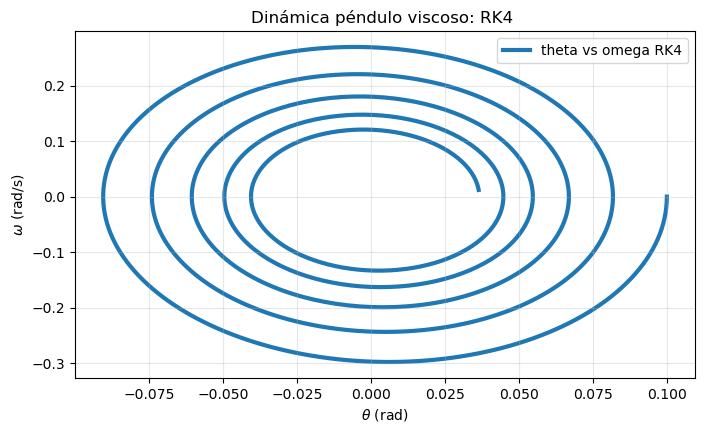

In [31]:
# Llamada a la función de simulación
# Execution parameters
t0 = 0.0
t_max = 10.0
dt = 0.01
x_0 = 0.1  # Initial position x1(0)
v_0 = 0.0  # Initial velocity x2(0)

# Running the simulation
t_rk, theta_rk, omega_rk = sim_rk4(f1, f_pendulo, t0, x_0, v_0, dt, t_max)
# Diagrama de fase
plt.figure(figsize=(8, 4.5))
    

    # Curva simulada que se actualiza
plt.plot(theta_rk, omega_rk, color="tab:blue", linestyle="-", label=f"theta vs omega RK4", lw=3, zorder = 0)
    
    
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$\omega$ (rad/s)")
plt.title("Dinámica péndulo viscoso: RK4 ")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

## b)
Como control, también grafique el mapa de fases Ɵ (t) vs. ω (t) y la evolución de la 
energía mecánica en el tiempo. Compare sus resultados contra el método de Euler 
explícito del Trabajo Práctico Número 1, ploteando de forma conjunta. ¿Para qué paso 
temporal dt ambos métodos dan soluciones notablemente diferentes?

### Euler

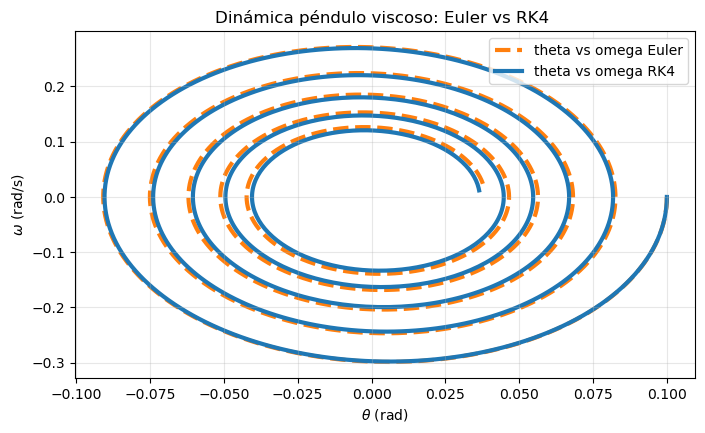

In [32]:

t0 = 0.0
t_max = 10.0
dt = 0.01
x_0 = 0.1  # Initial position x1(0)
v_0 = 0.0  # Initial velocity x2(0)
t0 = 0.0
t_max = 10.0
dt = 0.001
theta_0 = 0.1  # Ángulo inicial en radianes
omega_0 = 0.0  # Velocidad angular inicial

# Llamada a la función de simulación
t_euler, theta_euler, omega_euler = simular_euler(
    f=f_pendulo, 
    t0=t0, 
    y0=theta_0, 
    y01=omega_0, 
    dt=dt, 
    t_max=t_max
)
# Diagrama de fase
plt.figure(figsize=(8, 4.5))
    

    # Curva simulada que se actualiza
plt.plot(theta_euler, omega_euler, color="tab:orange", linestyle="--", label=f"theta vs omega Euler", lw=3, zorder = 0)
plt.plot(theta_rk, omega_rk, color="tab:blue", linestyle="-", label=f"theta vs omega RK4", lw=3, zorder = 0)    
    
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$\omega$ (rad/s)")
plt.title("Dinámica péndulo viscoso: Euler vs RK4 ")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

In [33]:

t0 = 0.0
t_max = 10.0
dt = 0.01
x_0 = 0.1  # Initial position x1(0)
v_0 = 0.0  # Initial velocity x2(0)
t0 = 0.0
t_max = 10.0
dt = 0.001
theta_0 = 0.1  # Ángulo inicial en radianes
omega_0 = 0.0  # Velocidad angular inicial

# Constantes fijas

# Decorador interactivo con el slider para dt
@interact(dt=FloatSlider(value=0.001, min=0.0001, max=0.05, step=0.0001, description=r"$dt$ (s):", readout_format='.4f'))
def diag_fases(dt):
    # 1. Corremos la simulación de Euler con el dt que marca el slider
    t_sim_e, theta_sim_e, omega_sim_e = simular_euler(f=f_pendulo, 
        t0=t0, 
        y0=theta_0, 
        y01=omega_0, 
        dt=dt, 
        t_max=t_max)

    t_sim_rk, theta_sim_rk, omega_sim_rk = sim_rk4(f1, f_pendulo, t0, x_0, v_0, dt, t_max)
    
    # 2. Calculamos la energía para esa simulación
    
    
    # 3. Armamos el gráfico
    plt.figure(figsize=(8, 4.5))
    
    # Curva exacta (fija de fondo para comparar)
    plt.plot(theta_sim_rk, omega_sim_rk, color="tab:blue", linestyle="-", label=f"theta vs omega RK4", lw=3, zorder = 0)
    
    # Curva simulada que se actualiza
    plt.plot(theta_sim_e, omega_sim_e, color="tab:orange", linestyle="--", label=f"theta vs omega Euler (dt = {dt:.4f})", lw=3, zorder = 0)
    
    # Límites fijos para que el gráfico no salte al mover el slider
    # (El límite de y está en 0.12 J porque dt grandes meten mucha energía artificial)
    plt.xlim(-0.12, 0.12)
    plt.ylim(-0.3, 0.3) 
    
    plt.xlabel(r"$\theta$ (rad)")
    plt.ylabel(r"$\omega$ (rad/s)")
    plt.title("Dinámica péndulo viscoso: diag de fase")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.001, description='$dt$ (s):', max=0.05, min=0.0001, readout_format='…

## c)
Compare su integración Runge-Kutta 4 también versus alguna rutina o paquete de 
Python (scipy.integrate). ¿Para qué paso temporal dt Runge-Kutta 4 ya no entrega 
resultados razonables?

In [9]:
#$$ \ddot \theta + b \dot \theta + \omega_0 ^2 sin(\theta) =0 $$
# \begin{cases}
# \dot \theta = \omega \\
# \dot \omega = -b \omega - \omega_0 ^2 sin(\theta) = -b \omega -\frac{g}{l}  sen(\theta)
# \end{cases}
#U[1] = omega
#U[0] = theta
# Define a function for the right side
# defino U = (theta, omega)
#defino funcion derivADA  de U, dU/dt = (omega, omegapunto (la ec diferencial))
g = 9.8
l = 1
b = 0.2
# pendulo linealizado prefuntar si usar el linealoizado o con el sen
def dU_dx_new(t, U):
    """Right side of the differential equation to be solved.
    U is a two-component vector with y=U[0] and z=U[1]. 
    Thus this function should return [y', z']
    """
    return [U[1], -b*U[1] -(g/l)*U[0]]

# initial condition U_0 = [y(0)=0, z(0)=y'(0)=0]
U_0 = [0.1, 0.]

t_true = np.linspace(0, 10, 200)  # Set up the mesh of x points
result = solve_ivp(dU_dx_new, (0, 10), U_0, t_eval=t_true)
theta_true = result.y[0,:]   # Ok, this is tricky.  For each x, result.y has two 
                        #  components.  We want the first component for all
                        #  x, which is y(x).  The 0 means the first index and 
                        #  the : means all of the x values.
omega_true = result.y[1,:]

In [10]:

t0 = 0.0
t_max = 10.0
dt = 0.01
x_0 = 0.1  # Initial position x1(0)
v_0 = 0.0  # Initial velocity x2(0)


# Constantes fijas

# Decorador interactivo con el slider para dt
@interact(dt=FloatSlider(value=0.01, min=0.01, max=0.5, step=0.01, description=r"$dt$ (s):", readout_format='.2f'))
def diag_fases(dt):
    # 1. Corremos la simulación de Euler con el dt que marca el slider


    t_sim_rk, theta_sim_rk, omega_sim_rk = sim_rk4(f1, f_pendulo, t0, x_0, v_0, dt, t_max)
    
    # 2. Calculamos la energía para esa simulación
    
    
    # 3. Armamos el gráfico
    plt.figure(figsize=(8, 4.5))
    
    # Curva exacta (fija de fondo para comparar)
    plt.plot(theta_sim_rk, omega_sim_rk, color="tab:blue", linestyle="-", label=f"theta vs omega RK4 (dt = {dt:.2f})", lw=4, zorder = 0)
    
    # Curva simulada que se actualiza
    plt.plot(theta_true, omega_true, color="tab:orange", linestyle="--", label=f"theta vs omega scypy integrate ivp ", lw=3, zorder = 0)
    
    # Límites fijos para que el gráfico no salte al mover el slider
    # (El límite de y está en 0.12 J porque dt grandes meten mucha energía artificial)
    plt.xlim(-0.12, 0.12)
    plt.ylim(-0.3, 0.3) 
    
    plt.xlabel(r"$\theta$ (rad)")
    plt.ylabel(r"$\omega$ (rad/s)")
    plt.title("Dinámica péndulo viscoso: diag de fase")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=0.01, description='$dt$ (s):', max=0.5, min=0.01, step=0.01), Output()…

## d)
Descarte el amortiguamiento (ahora b=0) y calcule y grafique la variación del período 
de oscilación como función del ángulo inicial, con valores para dichos ángulos:
0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3 y 1.5 radianes. 
Compare dichos tiempos contra el valor teórico de pequeñas oscilaciones. Grafique 
nuevamente la evolución de la energía mecánica en el tiempo. ¿Se conserva la energía?

In [16]:
def f_pendulo_d(t, x, v):
    b = 0
    g = 9.8
    L = 1.0
    return -b * v - (g / L) * np.sin(x)

$$
\omega_d = \sqrt{\omega_0^2 - \left(\frac{b}{2}\right)^2} = \sqrt{\frac{g}{L} - \left(\frac{b}{2}\right)^2}\\

T_d = \frac{2\pi}{\omega_d} = \frac{2\pi}{\sqrt{\frac{g}{L} - \left(\frac{b}{2}\right)^2}}
$$
$$
b = 0 \; y \; sin(\theta) \approx \theta \begin{cases}
\omega_0 = \sqrt{\frac{g}{L}}\\

T = \frac{2\pi}{\omega_0} = 2\pi\sqrt{\frac{L}{g}}
\end{cases}
$$
en el ejercicio comparo el T dfe pendulo ideal vs el T real sin linealizar ecuacion

Simulación lista: theta_0 = 0.1 rad --> T = 2.0088 s
Simulación lista: theta_0 = 0.3 rad --> T = 2.0188 s
Simulación lista: theta_0 = 0.5 rad --> T = 2.0388 s
Simulación lista: theta_0 = 0.7 rad --> T = 2.0700 s
Simulación lista: theta_0 = 0.9 rad --> T = 2.1138 s
Simulación lista: theta_0 = 1.1 rad --> T = 2.1700 s
Simulación lista: theta_0 = 1.3 rad --> T = 2.2429 s
Simulación lista: theta_0 = 1.5 rad --> T = 2.3329 s


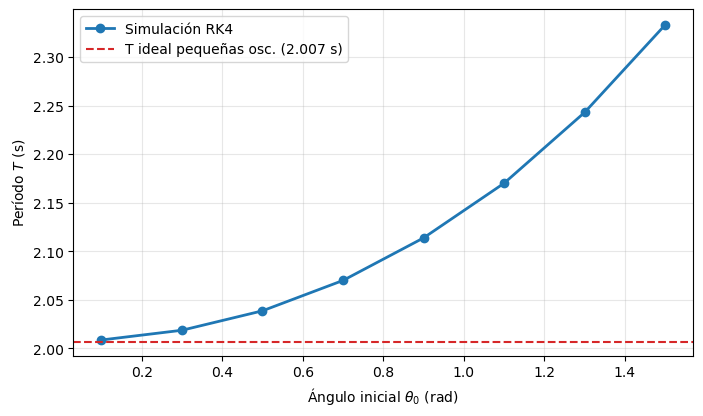

In [ ]:


# 1. Definir parámetros iniciales
t0 = 0.0
t_max = 20.0  
dt = 0.01
v_0 = 0.0 

# Ángulos desde 0.1 hasta 1.5 con paso de 0.2
angulos_iniciales = np.arange(0.1, 1.6, 0.2)

# 2. Listas vacías para guardar SOLO los resultados que nos interesan
angulos_guardados = []
periodos_guardados = []

# 3. Bucle para simular y extraer T
for x_0 in angulos_iniciales:
    # Corremos la simulación
    t_sim_rk, theta_sim_rk, omega_sim_rk = sim_rk4(f1, f_pendulo_d, t0, x_0, v_0, dt, t_max)
    
    # Buscamos los picos para calcular el período
    indices_picos, _ = find_peaks(theta_sim_rk)
    
    if len(indices_picos) > 1:
        tiempos_picos = t_sim_rk[indices_picos]
        T = np.mean(np.diff(tiempos_picos))
        
        # Guardamos el ángulo y su período
        angulos_guardados.append(x_0)
        periodos_guardados.append(T)
        
        print(f"Simulación lista: theta_0 = {x_0:.1f} rad --> T = {T:.4f} s")
    else:
        print(f"Fallo en theta_0 = {x_0:.1f}: Aumenta t_max para ver más oscilaciones.")


T_ideal = 2 * np.pi * np.sqrt(1.0 / 9.8)  # Constante teórica (L=1, g=9.8)

plt.figure(figsize=(8, 4.5))
# Graficamos la curva de la simulación
plt.plot(angulos_guardados, periodos_guardados, marker="o", color="tab:blue", label="Simulación RK4", lw=2)

# Graficamos la línea teórica constante
plt.axhline(y=T_ideal, color="tab:red", linestyle="--", label=f"T ideal pequeñas osc. ({T_ideal:.3f} s)")

plt.xlabel(r"Ángulo inicial $\theta_0$ (rad)")
plt.ylabel(r"Período $T$ (s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

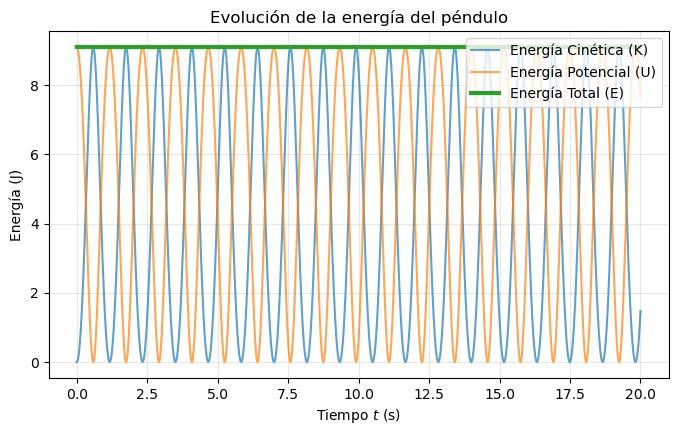

In [30]:

# Parámetros del sistema
m = 1.0  # Asumimos masa unitaria
g = 9.8
L = 1.0

# 1. Cálculo de las energías
energia_cinetica = 0.5 * m * (L * omega_sim_rk)**2
energia_potencial = m * g * L * (1 - np.cos(theta_sim_rk))
energia_total = energia_cinetica + energia_potencial

# 2. Gráfico de la evolución de la energía en el tiempo
plt.figure(figsize=(8, 4.5))

plt.plot(t_sim_rk, energia_cinetica, label="Energía Cinética (K)", color="tab:blue", alpha=0.7)
plt.plot(t_sim_rk, energia_potencial, label="Energía Potencial (U)", color="tab:orange", alpha=0.7)
plt.plot(t_sim_rk, energia_total, label="Energía Total (E)", color="tab:green", lw=3)

plt.xlabel(r"Tiempo $t$ (s)")
plt.ylabel(r"Energía (J)")
plt.title("Evolución de la energía del péndulo")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

In [34]:

t0 = 0.0
dt = 0.001
m = 1
L =1
x_0 = 0.1  # Initial position x1(0)
v_0 = 0.0  # Initial velocity x2(0)
def energia(theta, omega):
    E = (1/2) * m * l**2 *omega**2 + (1/2) * m *g*l *theta**2
    return E

# Constantes fijas

# Decorador interactivo con el slider para dt
@interact(t_max=FloatSlider(value=10, min=5, max=30, step=5, description=r"$t_max$ (s):", readout_format='.0f'))
def diag_fases(t_max):
    # 1. Corremos la simulación de Euler con el dt que marca el slider

    t_euler, theta_euler, omega_euler = simular_euler(
    f=f_pendulo_d, 
    t0=t0, 
    y0=theta_0, 
    y01=omega_0, 
    dt=dt, 
    t_max=t_max)
    t_sim_rk, theta_sim_rk, omega_sim_rk = sim_rk4(f1, f_pendulo_d, t0, x_0, v_0, dt, t_max)
    
    # 2. Calculamos la energía para esa simulación
    
    energia_rk = energia(theta_sim_rk, omega_sim_rk)
    energia_euler = energia(theta_euler, omega_euler)
    # 3. Armamos el gráfico
    plt.figure(figsize=(8, 4.5))
    
    plt.plot(t_sim_rk, energia_rk, label="Energía Total (E) rk 4", color="tab:green", lw=3)
    plt.plot(t_euler, energia_euler, label="Energía Total (E) Euler", color="tab:blue", lw=3)
    plt.xlabel(r"Tiempo $t$ (s)")
    plt.ylabel(r"Energía (J)")
    plt.title("Evolución de la energía del péndulo")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=10.0, description='$t_max$ (s):', max=30.0, min=5.0, readout_format='.…

# 2) 

## a)
$$
\text C\,\dfrac{dv}{dt} + \dfrac 1 {\text R} \, {v} = 0 \\
\frac{dv}{v} = -\frac{1}{RC} dt
$$
$$
𝑉_{out}⁡(𝑡)=𝑉⁡(1−𝑒^{−\frac{𝑡}{𝜏}}),

$$


Carga capacitor
$$
V_{in}−𝑉𝑅−𝑉𝑐=0\\
V_{in}−𝐼⁢𝑅−\frac{𝑞}{C} =0\\
V_{in}−𝑅⁢\frac{𝑑⁢𝑞}{𝑑⁢𝑡} − \frac{𝑞}{𝐶} =0
$$

$$
\frac{dq}{dt} = \frac{V_{in} C -q}{RC}\\
$$
$$
\int_0^q \frac{dq}{V_{in} C - q} = \frac{1}{RC} \int_0^t dt
$$
$ u = V_{in} C-q \, du = dq$
$$
-\int_0^q \frac{du}{u} = \frac{1}{RC} \int_0^t dt
$$
$$
ln(\frac{V_{in} C - q}{V_{in} C}) = - \frac{1}{RC}t
$$
$$
\frac{V_{in} C - q}{V_{in} C} = e^{-\frac{t}{RC}}
$$
$$
q(t) = C V_{in} ( 1- e^{-\frac{t}{RC}}) = Q(1-e^{-\frac{t}{\tau}})
$$
$$
I(t) = I_0 e^{-\frac{t}{\tau}}

$$
$$I = \frac{V_{in}}{R} - \frac{q}{RC}$$
$$I(t) = \frac{V_{in}}{R} e^{-\frac{t}{RC}}$$
$$V_{out} = \frac{q}{C}$$
$$V_{out}(t) = V_{in}(1 - e^{-\frac{t}{RC}})$$

## b)

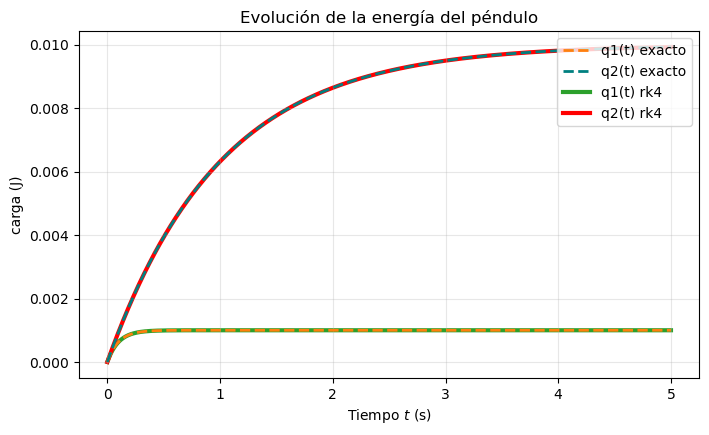

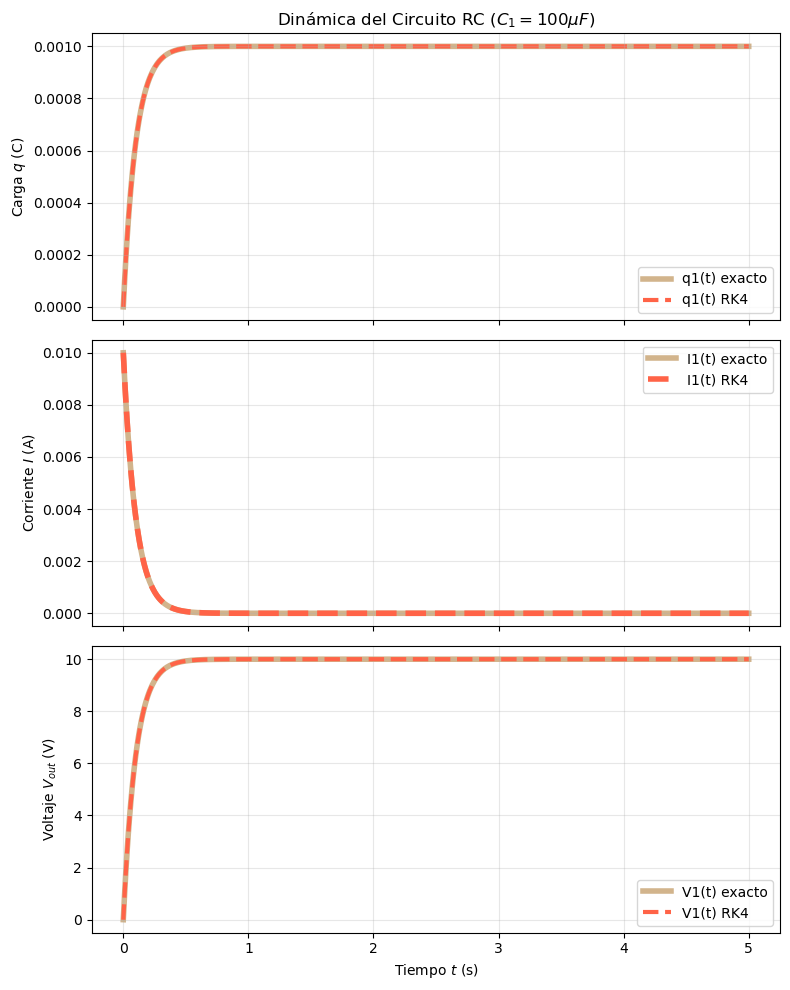

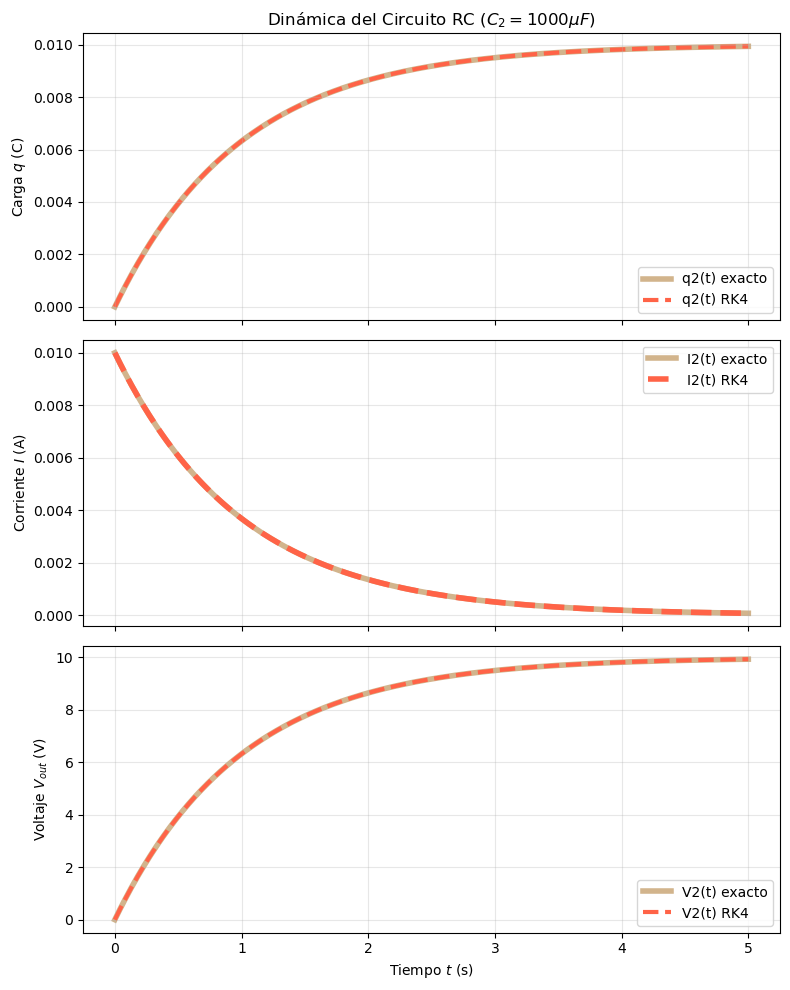

In [43]:
t0 =0
Vin = 10 #voltios, 
R = 1000 #ohm 
C1 = 100e-6 #µfaradios  
C2 = 1000e-6 #µfaradios
dt = 0.001
t_max = 5
t = np.linspace(0,5, 500)
q1_exacta = C1*Vin*(1-np.exp(-t/(R*C1)))
q2_exacta = C2*Vin*(1-np.exp(-t/(R*C2)))
I1_exacta = Vin/R - q1_exacta/(R*C1)
I2_exacta = Vin/R - q2_exacta/(R*C2)
V1_exacta = q1_exacta/C1
V2_exacta = q2_exacta/C2
def q_C1(t,q):
    return (Vin*C1 - q)/(R*C1)
def q_C2(t,q):
    I = (Vin*C2 - q)/(R*C2)
    return I

t_rk, q1_rk  = np.array(rk4(q_C1, t0, 0, dt, t_max))
t_rk, q2_rk  = np.array(rk4(q_C2, t0, 0, dt, t_max))
I1_rk = Vin/R - q1_rk/(R*C1)
I2_rk = Vin/R - q2_rk/(R*C2)
V1_rk = q1_rk/C1
V2_rk = q2_rk/C2
plt.figure(figsize=(8, 4.5))
plt.plot(t, q1_exacta, label="q1(t) exacto", linestyle = "--", color="tab:orange", lw=2, zorder = 5)
plt.plot(t, q2_exacta, label="q2(t) exacto", linestyle = "--", color="teal", lw=2, zorder = 5)
plt.plot(t_rk, q1_rk, label="q1(t) rk4", color="tab:green", lw=3, zorder = 0)
plt.plot(t_rk, q2_rk, label="q2(t) rk4", color="red", lw=3, zorder = 0)
plt.xlabel(r"Tiempo $t$ (s)")
plt.ylabel(r"carga (J)")
plt.title("Evolución de la energía del péndulo")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()



# Crear una figura con 3 paneles apilados que comparten el eje X (tiempo)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# --- Panel 1: Carga ---
ax1.plot(t, q1_exacta, label="q1(t) exacto", color="tan", lw=4, zorder=0)
ax1.plot(t_rk, q1_rk, label="q1(t) RK4", linestyle="--", color="tomato", lw=3, zorder=0)
ax1.set_ylabel("Carga $q$ (C)")
ax1.set_title(r"Dinámica del Circuito RC ($C_1 = 100 \mu F$)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# --- Panel 2: Corriente ---
ax2.plot(t, I1_exacta, label="I1(t) exacto", linestyle="-", color="tan", lw=4, zorder=0)
ax2.plot(t_rk, I1_rk, label="I1(t) RK4", linestyle = "--",  color="tomato", lw=4, zorder=2)
ax2.set_ylabel("Corriente $I$ (A)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# --- Panel 3: Voltaje ---
ax3.plot(t, V1_exacta, label="V1(t) exacto", color="tan", lw=4, zorder=0)
ax3.plot(t_rk, V1_rk, label="V1(t) RK4", linestyle="--", color="tomato", lw=3, zorder=2)
ax3.set_ylabel(r"Voltaje $V_{out}$ (V)")
ax3.set_xlabel("Tiempo $t$ (s)")
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Ajustar los márgenes para que no se superpongan los textos
plt.tight_layout()
plt.show()


# Crear una figura con 3 paneles apilados que comparten el eje X (tiempo)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# --- Panel 1: Carga ---
ax1.plot(t, q2_exacta, label="q2(t) exacto", color="tan", lw=4, zorder=0)
ax1.plot(t_rk, q2_rk, label="q2(t) RK4", linestyle="--", color="tomato", lw=3, zorder=0)
ax1.set_ylabel("Carga $q$ (C)")
ax1.set_title(r"Dinámica del Circuito RC ($C_2 = 1000 \mu F$)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# --- Panel 2: Corriente ---
ax2.plot(t, I2_exacta, label="I2(t) exacto", linestyle="-", color="tan", lw=4, zorder=0)
ax2.plot(t_rk, I2_rk, label="I2(t) RK4", linestyle = "--",  color="tomato", lw=4, zorder=2)
ax2.set_ylabel("Corriente $I$ (A)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# --- Panel 3: Voltaje ---
ax3.plot(t, V2_exacta, label="V2(t) exacto", color="tan", lw=4, zorder=0)
ax3.plot(t_rk, V2_rk, label="V2(t) RK4", linestyle="--", color="tomato", lw=3, zorder=2)
ax3.set_ylabel(r"Voltaje $V_{out}$ (V)")
ax3.set_xlabel("Tiempo $t$ (s)")
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Ajustar los márgenes para que no se superpongan los textos
plt.tight_layout()
plt.show()

 circuito en su estado estacionario (cuando $t \to \infty$): \\  
 El capacitor inicialmente descargado comienza a acumular electrones en sus placas. A medida que se llena, genera una diferencia de potencial (voltaje) que se opone a la batería. Cuando este voltaje iguala exactamente al de la fuente, la fuerza de repulsión impide que entren más electrones y el proceso se detiene.\
 Valores finales (estado estacionario):\
 Corriente final ($I$): 0 A. Una vez que el capacitor está lleno, se comporta como un circuito abierto y la corriente deja de circular.\
 Voltaje final ($V_{out}$): 10 V. Alcanza exactamente el valor de la fuente de alimentación $V_{in}$, sin importar el tamaño del capacitor.   \
 Carga final ($q = C \cdot V_{in}$): Depende de la capacidad de almacenamiento de cada capacitor.   \
 Para $C_1$ ($100 \mu F$): $1 \times 10^{-3}$ C (o 1 mC).\
 Para $C_2$ ($1000 \mu F$): $10 \times 10^{-3}$ C (o 10 mC).\
 ¿Cuánto tiempo debe transcurrir en cada caso?en la práctica física de laboratorio, se considera que un capacitor está totalmente cargado (al 99.3% de su capacidad) después de que transcurre un tiempo igual a $5\tau$ ($\tau = RC$).\
 Caso $C_1$: $\tau = 1000 \Omega \cdot 100\times 10^{-6} \text{ F} = 0.1 \text{ s}$. Por lo tanto, en la práctica tarda 0.5 segundos en cargarse.\
 Caso $C_2$: $\tau = 1000 \Omega \cdot 1000\times 10^{-6} \text{ F} = 1.0 \text{ s}$. Por lo tanto, en la práctica tarda 5.0 segundos en cargarse.

## c)
Compruebe que el método de Runge-Kutta 4 es, efectivamente, de orden 4. Para ello, 
genere corridas (de 0 a 1 segundo) con la cantidad de pasos siguientes N: 
10, 20, 40, 80, 160, 320, 640 y 1280 (dt será igual a 1 segundo/N).\
En cada caso, calcule el error en la carga q del capacitor al tiempo final respecto de la 
solución exacta y plotee en una escala log-log dicho error versus el tamaño del paso dt. La 
pendiente de la recta debería ser un valor muy cercano a 4

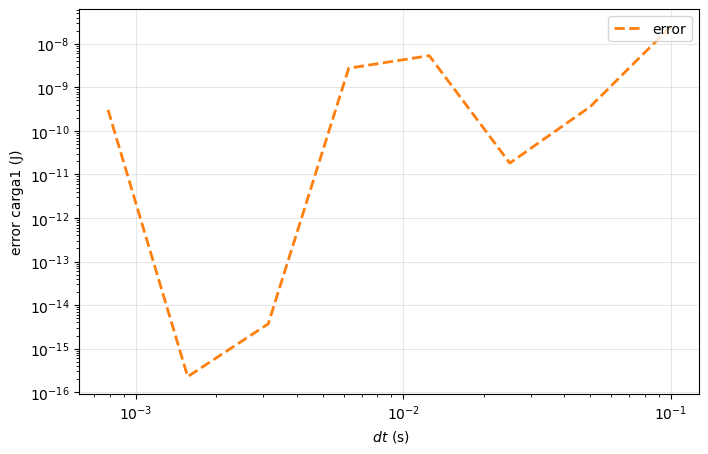

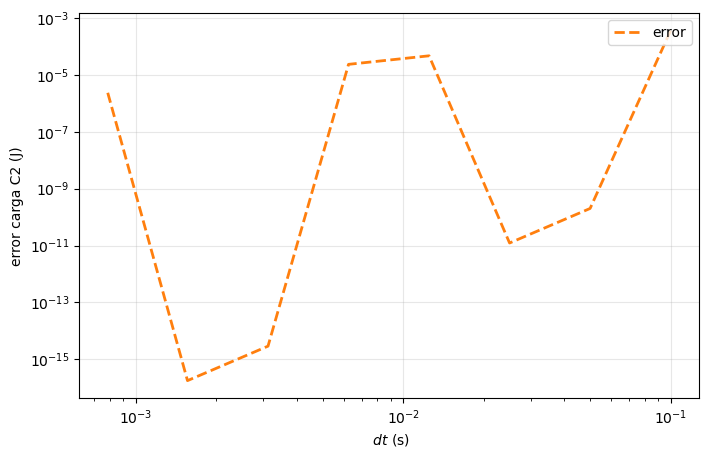

In [41]:
t0 = 0.0
t_max = 1.0
Vin = 10 #voltios, 
R = 1000 #ohm 
C1 = 100e-6 #µfaradios  
C2 = 1000e-6 #µfaradios
N_valores = [10, 20, 40, 80, 160, 320, 640, 1280]

errores = []
dts = []

# Calcular el valor exacto de la carga q en t = 1.0 (solo necesitas este número)
q_c = C1 * Vin * (1 - np.exp(-t_max / (R * C1)))

for N in N_valores:
    dt = 1.0 / N
    dts.append(dt)

    # 1. Correr tu función RK4 desde t0=0 hasta t_max=1 con el dt actual
    t_rk, q_rk = rk4(q_C1, t0, 0, dt, t_max)
    
    # 2. Extraer el último valor de la carga que calculó RK4
    q_rk_c = q_rk[-1]
    
    # 3. Calcular el error absoluto respecto a la solución exacta
    error = abs(q_rk_c - q_c)
    errores.append(error)

plt.figure(figsize=(8, 5))
plt.loglog(dts, errores, label="error", linestyle = "--", color="tab:orange", lw=2, zorder = 5)

plt.xlabel(r" $dt$ (s)")
plt.ylabel(r"error carga1 (J)")
#plt.title("Evolución de la energía del péndulo")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

errores2 = []
dts2 = []
q_c2 = C2 * Vin * (1 - np.exp(-t_max / (R * C2)))

for N in N_valores:
    dt = 1.0 / N
    dts2.append(dt)

    # 1. Correr tu función RK4 desde t0=0 hasta t_max=1 con el dt actual
    t_rk2, q_rk2 = rk4(q_C2, t0, 0, dt, t_max)
    
    # 2. Extraer el último valor de la carga que calculó RK4
    q_rk_c2 = q_rk2[-1]
    
    # 3. Calcular el error absoluto respecto a la solución exacta
    error = abs(q_rk_c2 - q_c2)
    errores2.append(error)

plt.figure(figsize=(8, 5))
plt.plot(dts2, errores2, label="error", linestyle = "--", color="tab:orange", lw=2, zorder = 5)
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r" $dt$ (s)")
plt.ylabel(r"error carga C2 (J)")
#plt.title("Evolución de la energía del péndulo")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

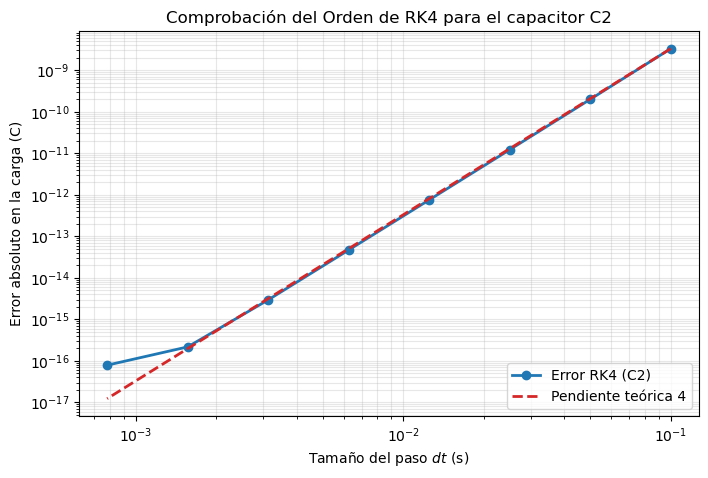

In [42]:


# Parámetros fijos
t0 = 0.0
t_max = 1.0
Vin = 10 
R = 1000 
C2 = 1000e-6 
N_valores = [10, 20, 40, 80, 160, 320, 640, 1280]

errores2 = []
dts2 = []

for N in N_valores:
    dt = 1.0 / N
    dts2.append(dt)

    # 1. Correr tu función RK4
    t_rk2, q_rk2 = rk4(q_C2, t0, 0, dt, t_max)
    
    # 2. Extraer el tiempo final REAL y la carga que calculó RK4
    t_final_real = t_rk2[-1]
    q_rk_c2 = q_rk2[-1]
    
    # 3. Calcular la solución exacta evaluada en ese TIEMPO REAL
    q_exacta_final = C2 * Vin * (1 - np.exp(-t_final_real / (R * C2)))
    
    # 4. Calcular el error absoluto
    error = abs(q_rk_c2 - q_exacta_final)
    errores2.append(error)

# --- Armado del Gráfico ---
plt.figure(figsize=(8, 5))

# Graficamos el error simulado con marcadores para ver los puntos
plt.loglog(dts2, errores2, marker="o", label="Error RK4 (C2)", color="tab:blue", lw=2)

# Graficamos una recta teórica de pendiente 4 (O(dt^4)) anclada al primer punto
referencia_dt4 = [errores2[0] * (paso / dts2[0])**4 for paso in dts2]
plt.loglog(dts2, referencia_dt4, linestyle="--", color="tab:red", label="Pendiente teórica 4", lw=2)

plt.xlabel("Tamaño del paso $dt$ (s)")
plt.ylabel("Error absoluto en la carga (C)")
plt.title("Comprobación del Orden de RK4 para el capacitor C2")
plt.legend(loc="lower right")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## d)


1. Planteo de la Ecuación DiferencialAl invertir la polaridad de la fuente continua, el potencial de la fuente pasa a actuar en sentido opuesto \
($-\varepsilon$ o $-V_{in}$).\ Aplicando la ley de mallas de Kirchhoff:$$-\varepsilon - I R - \frac{q}{C} = 0$$Sustituyendo la corriente por la tasa de variación de la carga ($I = \frac{dq}{dt}$), se obtiene la nueva ecuación diferencial lineal de primer orden:$$R \frac{dq}{dt} + \frac{q}{C} = -\varepsilon$$2. Solución para la Carga $q(t)$Considerando la condición inicial de que el capacitor se encuentra totalmente cargado al momento de invertir la polaridad ($q(0) = C\varepsilon$), la solución de la ecuación diferencial resulta:$$q(t) = C\varepsilon \left( 2e^{-\frac{t}{RC}} - 1 \right)$$3. Solución para la Corriente $I(t)$Derivando la expresión de la carga respecto al tiempo ($I(t) = \frac{dq}{dt}$), obtenemos la corriente del circuito:$$I(t) = -\frac{2\varepsilon}{R} e^{-\frac{t}{RC}}$$(Nota: El signo negativo indica que la corriente fluye en sentido inverso al de la carga inicial mientras el capacitor se descarga y vuelve a cargarse con la polaridad opuesta).4. Solución para la Tensión entre las Placas $V_{out}(t)$Utilizando la relación fundamental del capacitor ($V_{out} = \frac{q}{C}$):$$V_{out}(t) = \varepsilon \left( 2e^{-\frac{t}{RC}} - 1 \right)$$

Fase de descarga: Al invertir la fuente, el voltaje inicial del capacitor y el de la nueva fuente se suman en contra del sentido original, \ 
provocando que el capacitor empiece a descargarse rápidamente a través de la resistencia. Durante este proceso, la corriente fluye en sentido inverso.Transición y recarga inversa: \Una vez que la carga del capacitor llega a cero (se descarga por completo), la fuente continua ejerce trabajo para volver a cargarlo, pero con la polaridad invertida (las placas cambian el signo de su carga).Estado estacionario: \
El proceso se detiene cuando el voltaje entre las placas del capacitor vuelve a igualarse en magnitud al de la nueva fuente, pero con signo opuesto.\
Valores finales (en el estado estacionario, cuando $t \to \infty$):Corriente eléctrica final ($I$): 0 A. Al igual que en el caso anterior, una vez que el capacitor alcanza su nueva carga de equilibrio, se comporta como un circuito abierto y la corriente deja de circular por completo.Carga final ($q$): $-C\varepsilon$ (o $-C V_{in}$). El capacitor termina totalmente cargado pero con polaridad invertida respecto a su estado inicial.Voltaje final entre las placas ($V_{out}$): $-\varepsilon$ (o $-V_{in}$). El voltaje final coincide exactamente con el valor de la fuente de alimentación con su nuevo signo invertido.

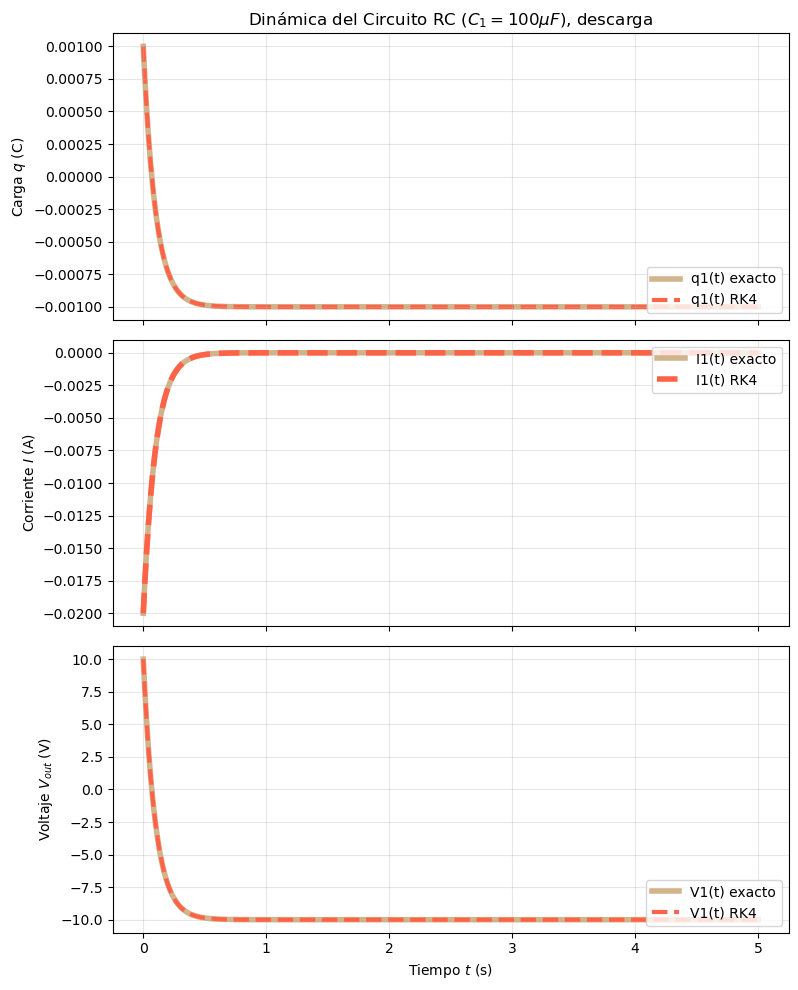

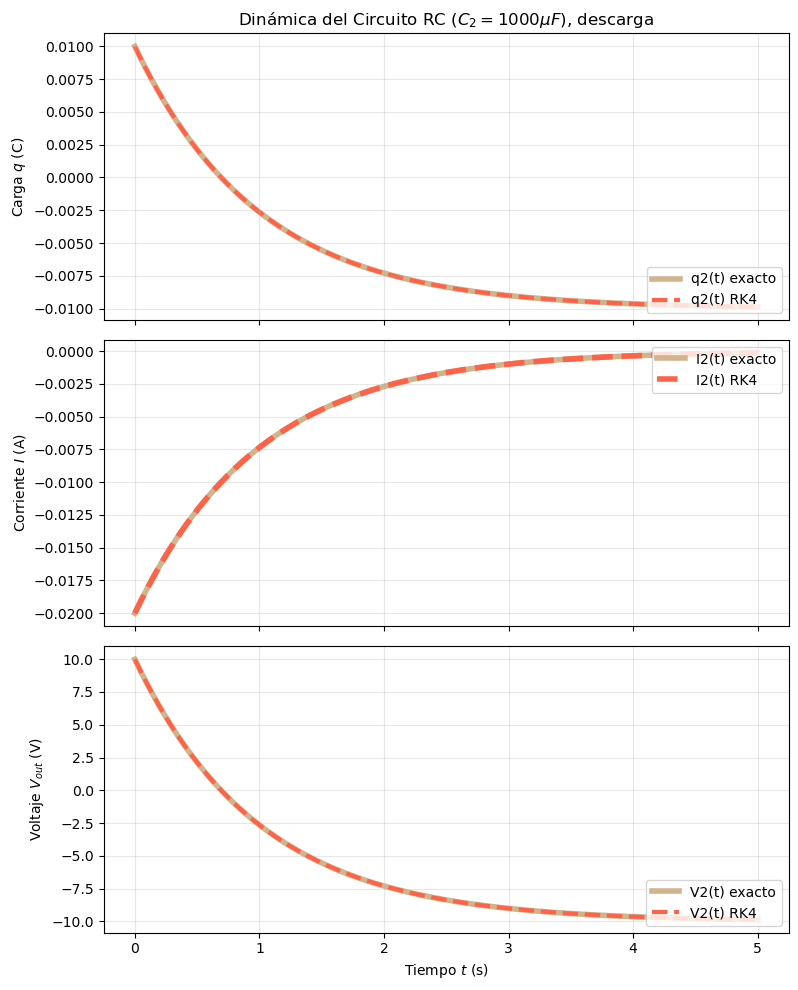

In [46]:
# 1. Definir funciones específicas para cada capacitor
def q_invertido_1(t, q):
    return (-Vin - q / C1) / R

def q_invertido_2(t, q):
    return (-Vin - q / C2) / R

# 2. Correr RK4 con la nueva condición inicial (q_inicial = C2 * Vin)

Vin = 10 #voltios, 
R = 1000 #ohm 
C1 = 100e-6 #µfaradios  
C2 = 1000e-6 #µfaradios
t0 = 0.0
t_max = 5.0
dt = 0.001
q_inicial1 = C1 * Vin  # Totalmente cargado con la polaridad original
q_inicial2 = C2 * Vin

# 1. Soluciones Exactas para el caso d)
t = np.linspace(t0, t_max, 500)
q1_exacta_d = C1 * Vin * (2 * np.exp(-t / (R * C1)) - 1)
I1_exacta_d = -(2 * Vin / R) * np.exp(-t / (R * C1))
V1_exacta_d = Vin * (2 * np.exp(-t / (R * C1)) - 1)
t_rk_d1, q_rk_d1 = rk4(q_invertido_1, t0, q_inicial1, dt, t_max)

# 3. Calcular la corriente y el voltaje a partir de los resultados de q
q_rk_d1 = np.array(q_rk_d1)
V_rk_d1 = q_rk_d1 / C1
I_rk_d1 = (-Vin - V_rk_d1) / R  # O usando la ecuación diferencial

q2_exacta_d = C2 * Vin * (2 * np.exp(-t / (R * C2)) - 1)
I2_exacta_d = -(2 * Vin / R) * np.exp(-t / (R * C2))
V2_exacta_d = Vin * (2 * np.exp(-t / (R * C2)) - 1)
t_rk_d2, q_rk_d2 = rk4(q_invertido_2, t0, q_inicial2, dt, t_max)

# 3. Calcular la corriente y el voltaje a partir de los resultados de q
q_rk_d2 = np.array(q_rk_d2)
V_rk_d2 = q_rk_d2 / C2
I_rk_d2 = (-Vin - V_rk_d2) / R  # O usando la ecuación diferencial

# Crear una figura con 3 paneles apilados que comparten el eje X (tiempo)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# --- Panel 1: Carga ---
ax1.plot(t, q1_exacta_d, label="q1(t) exacto", color="tan", lw=4, zorder=0)
ax1.plot(t_rk_d1, q_rk_d1, label="q1(t) RK4", linestyle="--", color="tomato", lw=3, zorder=0)
ax1.set_ylabel("Carga $q$ (C)")
ax1.set_title(r"Dinámica del Circuito RC ($C_1 = 100 \mu F$), descarga")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# --- Panel 2: Corriente ---
ax2.plot(t, I1_exacta_d, label="I1(t) exacto", linestyle="-", color="tan", lw=4, zorder=0)
ax2.plot(t_rk_d1, I_rk_d1, label="I1(t) RK4", linestyle = "--",  color="tomato", lw=4, zorder=2)
ax2.set_ylabel("Corriente $I$ (A)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# --- Panel 3: Voltaje ---
ax3.plot(t, V1_exacta_d, label="V1(t) exacto", color="tan", lw=4, zorder=0)
ax3.plot(t_rk_d1, V_rk_d1, label="V1(t) RK4", linestyle="--", color="tomato", lw=3, zorder=2)
ax3.set_ylabel(r"Voltaje $V_{out}$ (V)")
ax3.set_xlabel("Tiempo $t$ (s)")
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Ajustar los márgenes para que no se superpongan los textos
plt.tight_layout()
plt.show()
# Crear una figura con 3 paneles apilados que comparten el eje X (tiempo)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# --- Panel 1: Carga ---
ax1.plot(t, q2_exacta_d, label="q2(t) exacto", color="tan", lw=4, zorder=0)
ax1.plot(t_rk_d2, q_rk_d2, label="q2(t) RK4", linestyle="--", color="tomato", lw=3, zorder=0)
ax1.set_ylabel("Carga $q$ (C)")
ax1.set_title(r"Dinámica del Circuito RC ($C_2 = 1000 \mu F$), descarga")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# --- Panel 2: Corriente ---
ax2.plot(t, I2_exacta_d, label="I2(t) exacto", linestyle="-", color="tan", lw=4, zorder=0)
ax2.plot(t_rk_d2, I_rk_d2, label="I2(t) RK4", linestyle = "--",  color="tomato", lw=4, zorder=2)
ax2.set_ylabel("Corriente $I$ (A)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# --- Panel 3: Voltaje ---
ax3.plot(t, V2_exacta_d, label="V2(t) exacto", color="tan", lw=4, zorder=0)
ax3.plot(t_rk_d2, V_rk_d2, label="V2(t) RK4", linestyle="--", color="tomato", lw=3, zorder=2)
ax3.set_ylabel(r"Voltaje $V_{out}$ (V)")
ax3.set_xlabel("Tiempo $t$ (s)")
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Ajustar los márgenes para que no se superpongan los textos
plt.tight_layout()
plt.show()

## f)

e) Ahora el voltaje de entrada deja de ser constante y depende del tiempo. Usando la ley 
de Ohm y la relación carga (Q) - voltaje (Vout) en un capacitor, podemos escribir las 
ecuaciones que gobiernan el circuito:
I . R = Vin – Vout , Q = C . Vout , I = dQ/dt
Sustituyendo se encuentra que debe satisfacerse la ecuación siguiente: 
dVout/dt = (Vin – Vout) / (R.C)\\

f) Considere que la señal de entrada Vin(t) es del tipo de una onda cuadrada de amplitud 1 
voltio y frecuencia 1 Hertz (una oscilación en cada segundo). Escriba un programa para 
resolver la ecuación para Vout(t) usando el método de Runge-Kutta 4 para diferentes 
valores de RC:
0.001 s, 0.01 s, 0.1 s, 1 s, y 10 s.
Recuerde que el paso de integración debe ser bastante menor que 0,001 segundos. 
Compare las salidas. ¿Qué observa?

$$
I R  = V_{in} - V_{out} \\

Q = C V_{out} \\

I = \frac{dQ}{dt} \\

\frac{dV_{out}}{dt} = \frac{V_{in} - V_{out}}{RC}
$$

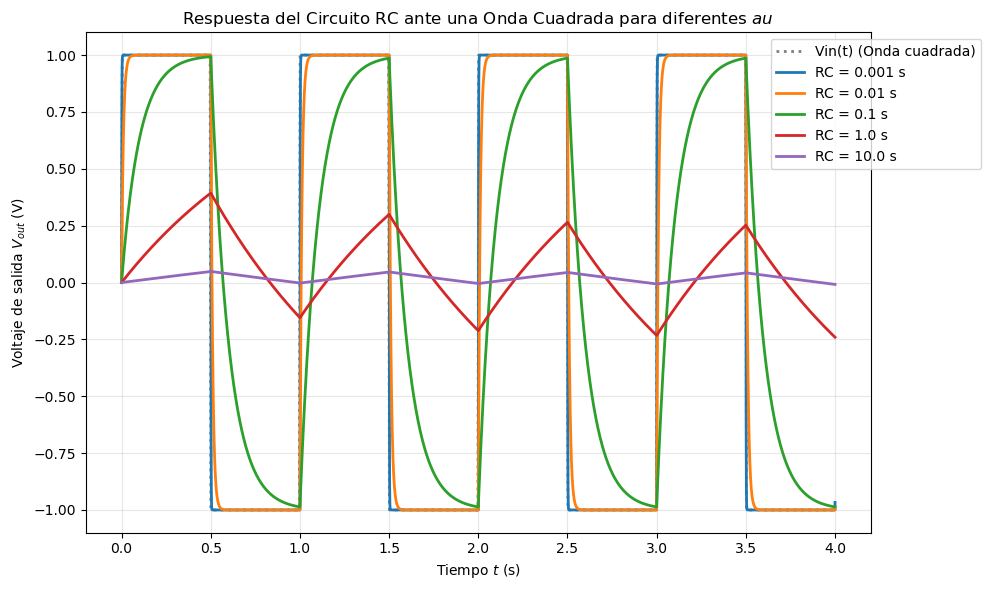

In [7]:
def Vin_cuadrada(t):
    # Frecuencia f = 1 Hz -> Periodo T = 1 s. Cambia de signo cada 0.5 s.
    return np.sign(np.sin(2 * np.pi * 1 * t))

def dVout_dt(t, V, tau):
    Vin = Vin_cuadrada(t)
    return (Vin - V) / (tau)


V0 = 0.0

t0 = 0.0
t_max = 4.0
dt = 0.0001


# Valores de RC (tau) 
tau_valores = [0.001, 0.01, 0.1, 1.0, 10.0]

# --- Gráfico comparativo ---
plt.figure(figsize=(10, 6))

# Onda de entrada de referencia (gris punteada)
t_ref = np.linspace(t0, t_max, 1000)
plt.plot(t_ref, Vin_cuadrada(t_ref), label="Vin(t) (Onda cuadrada)", color="gray", linestyle=":", lw=2)

# Bucle para simular y graficar cada valor de tau
for tau in tau_valores:
    # Usamos una función lambda para congelar el valor de tau que espera dVout_dt
    f_tau = lambda t, V: dVout_dt(t, V, tau)
    
    t_rk, V_rk = rk4(f_tau, t0, V0, dt, t_max)
    plt.plot(t_rk, V_rk, label=f"RC = {tau} s", lw=2)

plt.xlabel("Tiempo $t$ (s)")
plt.ylabel("Voltaje de salida $V_{out}$ (V)")
plt.title("Respuesta del Circuito RC ante una Onda Cuadrada para diferentes $\tau$")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()